0. Imports

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

1. Carregando o conjunto de dados

Carregando o conjunto de dados e apresentando as informações e as primeiras linhas do conjunto de dados:

In [ ]:
df = pd.read_csv('../data/raw/Churn_Modelling.csv')
df.info() 
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


2. Data preprocessing

2.1. Verificando a quantidade de valores ausentes (nulos) nas colunas do dataframe:

In [3]:
'''Pegando a quantidade de nulos de cada coluna com os método isnull + sum, dividindo pelo total de números 
e multiplicando por 100 para obter uma porcentagem'''
(df.isnull().sum()/len(df))*100

RowNumber          0.0
CustomerId         0.0
Surname            0.0
CreditScore        0.0
Geography          0.0
Gender             0.0
Age                0.0
Tenure             0.0
Balance            0.0
NumOfProducts      0.0
HasCrCard          0.0
IsActiveMember     0.0
EstimatedSalary    0.0
Exited             0.0
dtype: float64

Não existem valores nulos em nenhuma coluna, portanto nenhum tratamento é necessário.

2.2. Verificando valores discrepantes nas colunas:

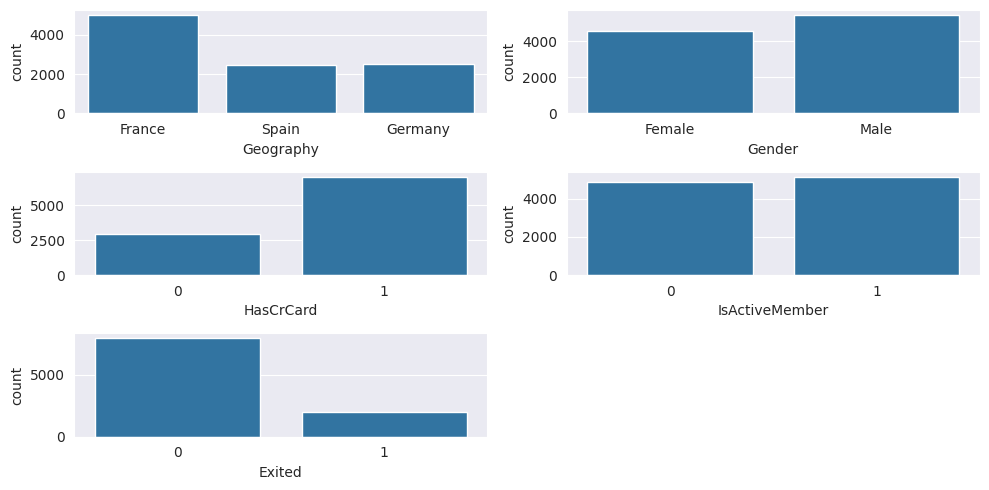

In [ ]:
#Colunas categóricas/numéricas discretas
sns.set_style("darkgrid")
plt.figure(figsize=(10, 5))

cols = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember', 'Exited']
for i in range(5):
    plt.subplot(3, 2, i+1)
    #Plotando gráfico de barras contando a frequência
    sns.countplot(x=df[cols[i]])

plt.tight_layout()

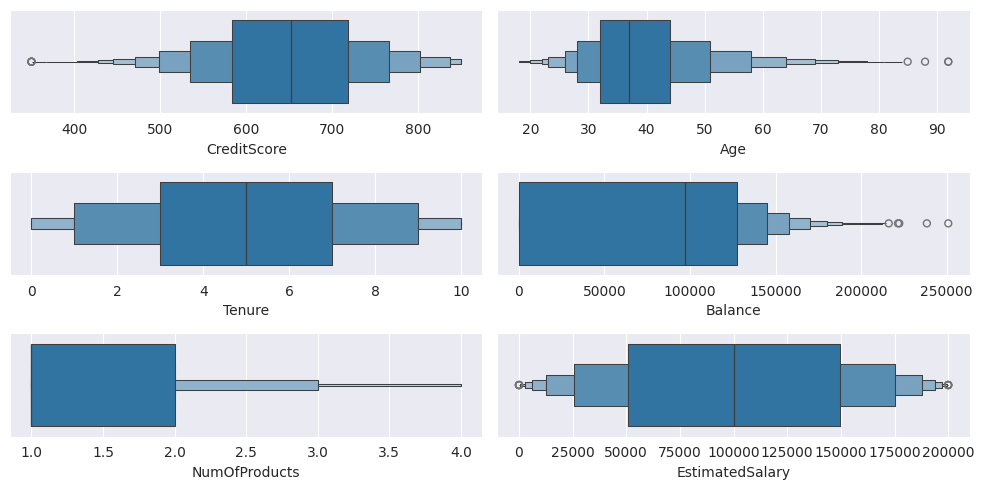

In [6]:
#Colunas numéricas contínuas
plt.figure(figsize=(10, 5))

cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
for i in range(6):
    #Criando uma grade de 3 linhas e 2 colunas
    plt.subplot(3, 2, i+1)
    #Criando boxenplot para ver os valores discrepantes
    sns.boxenplot(x=df[cols[i]])

plt.tight_layout()

Considerei os outliers (valores atípicos) como relevantes para a análise; portanto, optei por não removê-los.

2.3. Explorando estatísticas básicas das colunas:

In [11]:
#Colunas categóricas/numéricas discretas
cols = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember', 'Exited']

print(f'Frequência de cada valor:\n')
for i in range(5):
    #value_counts mostra a distribuição de variáveis categóricas
    print(f'{df[cols[i]].value_counts(normalize=True)*100}\n') #normalize faz a frequência ser relativa (%)

Frequência de cada valor:

Geography
France     50.14
Germany    25.09
Spain      24.77
Name: proportion, dtype: float64

Gender
Male      54.57
Female    45.43
Name: proportion, dtype: float64

HasCrCard
1    70.55
0    29.45
Name: proportion, dtype: float64

IsActiveMember
1    51.51
0    48.49
Name: proportion, dtype: float64

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64



In [9]:
#Colunas numéricas contínuas
cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
resume_num = df[cols].describe() #Selecionando todas as linhas e obtendo descrição dos dados das colunas
resume_num

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,100090.239881
std,96.653299,10.487806,2.892174,62397.405202,0.581654,57510.492818
min,350.000000,18.000000,0.000000,0.000000,1.000000,11.580000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,51002.110000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,100193.915000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,149388.247500
max,850.000000,92.000000,10.000000,250898.090000,4.000000,199992.480000


Obs.: O dataset considera para dados pessoas que foram clientes e já saíram, então nem todos os dados são só de quem ainda é cliente.

- **Geography:**
  * 50,14% são franceses.
- **HasCrCard:**
  * 70,55% possuem cartão de crédito.
- **IsActiveMember:**
  * 51,51% são ativos.
- **Exited:**
  * 79,63% deixaram o banco.
- **CreditScore:**
  * Média: 650,5288;
  * Máximo: 850;
  * 50% têm pontuação de crédito inferior a 652.
- **Age:**
  * Média: 38,9218;
  * Máximo: 92;
  * 75% têm menos de 44 anos.
- **Tenure:**
  * Média: 5,0128;
  * Máximo: 10;
  * Tempo de associação uniforme.
- **Balance:**
  * Média: 76.485,889288;
  * Máximo: 250.898,09;
  * Pelo menos 25% têm saldo igual a 0 e dispersão de aproximadamente 0,82, indicando valores muito dispersos e heterogêneos.
- **NumOfProducts:**
  * Média: 1.5302;
  * Máximo: 4;
  * Mais de 50% (menos de 75%) estão abaixo da média.
- **Balance:**
  * Média: 100.090,239881;
  * Máximo: 199.992,48;
  * Valores aparentemente uniformes, mas o salário estimado mais baixo é 11,58.

3. Transformação de Dados

- As colunas presentes no conjunto de dados já contam bem a história dos clientes, portanto não utilizei engenharia de recursos;
- Não houve necessidade de padronização ou normalização, pois nenhum algoritmo de aprendizado de máquina será utilizado.

4. Mineração de dados

4.1. Plotando histogramas e gráficos de barras das colunas principais para análise univariada:

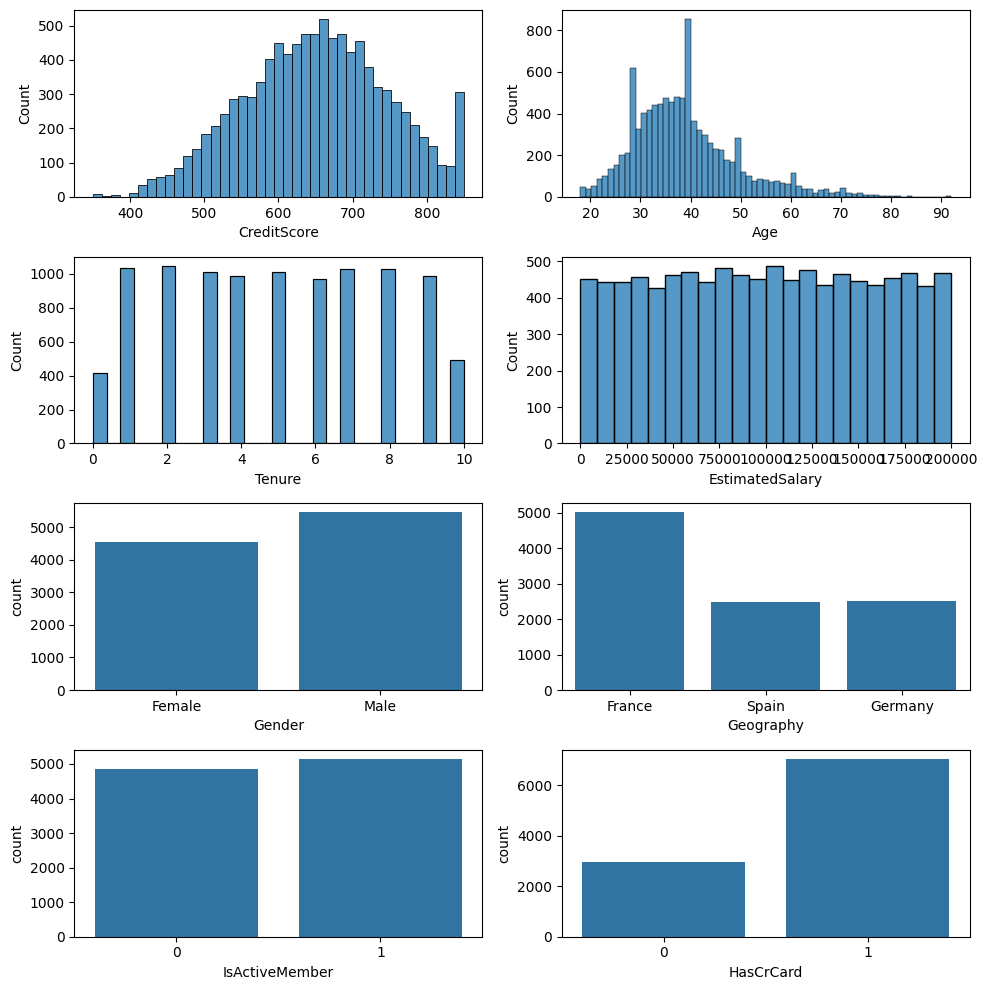

In [ ]:
plt.figure(figsize=(10, 10))

cols = ['CreditScore', 'Age', 'Tenure', 'EstimatedSalary', 'Gender', 'Geography', 'IsActiveMember', 'HasCrCard']
for i, col in enumerate(cols):
    plt.subplot(4, 2, i+1)
    if i<4:
        sns.histplot(data=df, x=col)
    else:
        sns.countplot(data=df, x=col)

plt.tight_layout()

- **CreditScore:** A distribuição é simétrica, com a maioria das pontuações de crédito dos clientes concentradas entre 600 e 700. Existem casos atípicos com um número elevado de pontuações de crédito;
- **Age:** A distribuição é assimétrica à esquerda, o que significa que a maioria dos clientes é mais jovem, concentrando-se principalmente entre 30 e 50 anos, com alguns números muito mais altos do que outros na mesma faixa etária, e também há casos de pessoas muito idosas;
- **Tenure:** A distribuição do tempo de associação dos clientes em anos é aproximadamente uniforme. Existem casos atípicos com clientes que têm muito pouco tempo (entre 0 e 1) e muito tempo (entre 9 e 10);
- **EstimatedSalary:** A distribuição da estimativa da renda dos clientes é muito uniforme;
- **Gender:** A distribuição do CreditScore é ligeiramente uniforme entre os gêneros, com os homens se destacando;
- **Geography:** A distribuição concentra aproximadamente 50% dos clientes residentes na França, sendo a outra metade dividida igualmente entre os demais;
- **IsActiveMember:** A distribuição é uniforme, com pouco mais de 50% dos clientes ativos;
- **HasCard:** A maioria dos clientes possui cartão, aproximadamente o dobro daqueles que não o possuem.

4.2. Explorando as relações, para a análise bivariada, entre:

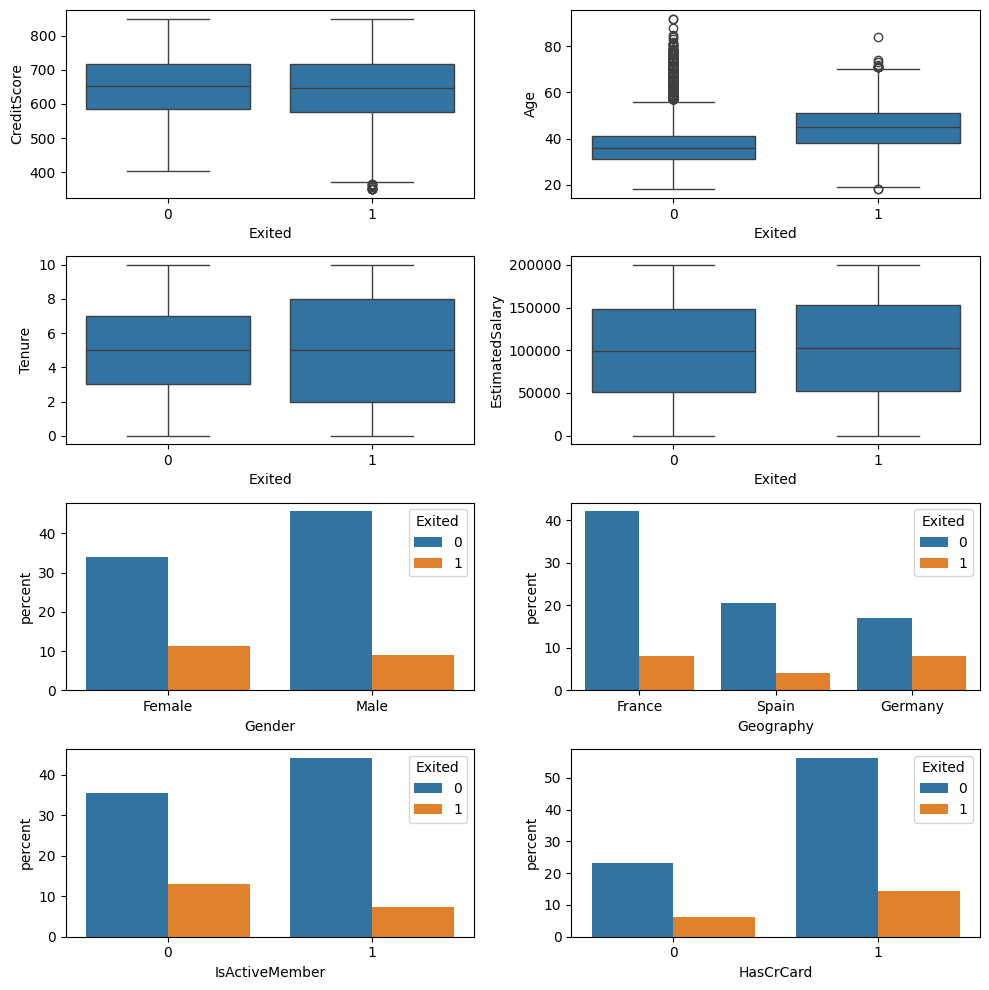

In [ ]:
plt.figure(figsize=(10, 10))

cols = ['CreditScore', 'Age', 'Tenure', 'EstimatedSalary', 'Gender', 'Geography', 'IsActiveMember', 'HasCrCard']
for i in range(8):
    plt.subplot(4, 2, i+1)
    if i<=3:
        sns.boxplot(x='Exited', y=cols[i], data=df)
    else:
        sns.countplot(x=cols[i], hue='Exited', data=df, stat='percent')

plt.tight_layout()

- **Exited x Credit Score:** A saída ou permanência é uniforme em relação à pontuação de crédito, ou seja, não há diferença clara entre aqueles que saíram e aqueles que permaneceram. Existem alguns casos atípicos em relação aos que saíram, indicando clientes com valores que se desviam da tendência geral;
- **Exited x Age:** A idade mediana dos clientes que permaneceram no programa varia entre 30 e 40 anos, sendo que metade dos que continuaram tinham entre 30 e pouco mais de 40 anos, com alguns idosos (acima de 50 anos) entre os que ficaram. A idade mediana dos clientes que saíram do programa varia entre 40 e 50 anos, sendo que metade dos que saíram tinham entre pouco menos de 40 e 50 anos, com alguns idosos (acima de 70 anos) entre os que saíram;
- **Exited x Tenure:** A duração mediana da assinatura dos clientes que permaneceram é de cerca de 5 anos, sendo que metade dos que continuaram tinha entre 3 e 7 anos de assinatura. Já a duração mediana da assinatura dos clientes que cancelaram é de cerca de 5 anos, com metade dos que permaneceram tendo entre pouco mais de 2 e pouco menos de 7 anos de assinatura;
- **Exited x Estimated Salary:** A permanência ou saída da empresa é uniforme em relação ao salário estimado; portanto, o salário não parece influenciar a decisão de sair;
- **Exited x Gender:** Cerca de 10 a 15% das clientes mulheres deixaram o banco, enquanto cerca de 10% dos clientes homens também o fizeram;
- **Exited x Geography:** Cerca de 5 a 10% dos clientes franceses e alemães deixaram o banco, enquanto os clientes espanhóis representam cerca de 5%;
- **Exited x Is Active Member:** Entre os clientes inativos, cerca de 10 a 15% cancelaram o serviço, enquanto entre os clientes ativos, esse percentual é de aproximadamente 5 a 10%. A taxa de cancelamento de clientes inativos é cerca de duas vezes maior que a de clientes ativos.
- **Exited vs. HasCreditCard:** Entre os clientes sem cartão de crédito, cerca de 5% cancelaram a assinatura, enquanto entre os que possuíam cartão, esse percentual foi de aproximadamente 15%. A taxa de cancelamento entre os clientes sem cartão é cerca de três vezes maior do que entre os que possuem.

5. Insights e Conclusões

- Age, Tenure, Gender, Geography, IsActiveMember e HasCrCard fornecem dados interessantes dados referentes às saídas;
- Diversos fatores influenciam a produção, sem que se observe um padrão definido em relação a fatores categóricos ou numéricos;
- CreditScore, Age e NumOfProducts apresentam valores discrepantes, sendo que todos representam valores discrepantes genuínos.